# EDA v0 — Polish CitationBench (raw scraped data)

**Autor:** Magdalena Sochacka (s25508), PJATK 2026
**Data:** 2026-05-16 (Iteracja 0 — feasibility test po rotacji domeny psychiatria → farmakologia, ale corpus consumer-rights już zescrapowany dla **probe layer search** + halu detection pipeline)
**Dane:** `main_project/data/raw/` (3 strata, **5,150 records** total)
**Cel notebooka:** ground-truth EDA przed budową retrieval indexu (Qdrant) — zidentyfikować quality issues, oszacować embedding cost, podać input dla decyzji filtering w Iter. 1.

## Spis sekcji
- **A.** Setup + data loading (workaround vs zepsutego `dataset_builder` dla ELI)
- **B.** Dataset overview (counts, size distribution, schema validation)
- **C.** ELI ustawy — per ustawa stats, chunk length distribution, citation format validation
- **D.** UOKiK Q&A — per category, citation density, most-cited statutes
- **E.** Consumer questions — per source, topic distribution, length per source
- **F.** Cross-source analysis — topic coverage matrix, citation overlap, token estimates
- **G.** Konkluzje + rekomendacje dla Iter. 1


## A. Setup

⚠ **Schema mismatch finding:** `src.halu.dataset_builder.load_eli_chunks` rzuca walidację bo raw ELI JSONL nie zawiera pól `chunk_id` ani `ustawa_data_uchwalenia` (data jest zagnieżdżona w `metadata.data_uchwalenia`, klucz to `para` zamiast `paragraf`). Notebook stosuje lokalny adapter `_normalize_eli_record()` — **TODO Iter. 1: zsynchronizować schema vs scraper output** (decyzja: zmienić scraper czy schema).

In [1]:
import json
import logging
import unicodedata
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path
from typing import Any, Iterator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pydantic import ValidationError

# Setup
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(message)s")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"] = ["DejaVu Sans"]  # PL diacritics

# Repo paths (relative do notebook lokalizacji)
NOTEBOOK_DIR = Path.cwd()  # main_project/notebooks
RAW_DIR = NOTEBOOK_DIR.parent / "data" / "raw"
assert RAW_DIR.exists(), f"Brak raw dir: {RAW_DIR}"
print(f"Raw data dir: {RAW_DIR}")
print(f"Subdirs: {[p.name for p in RAW_DIR.iterdir() if p.is_dir()]}")

Raw data dir: D:\diplomma\main_project\data\raw
Subdirs: ['consumer_documents_2026-05-16', 'consumer_questions_polish_2026-05-16', 'eli_ustawy_konsumenckie_2026-05-16', 'extended_consumer_2026-05-16', 'uokik_qa_2026-05-16']


In [2]:
# Imports z src.halu (Pydantic schemas)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR.parent))
from src.halu.schemas import ConsumerQuestion, ConsumerSource, LegalChunk, QAGoldPair


def _parse_date(value: Any):
    if isinstance(value, str):
        return datetime.fromisoformat(value[:10]).date()
    return value


def _normalize_eli_record(record: dict) -> dict:
    """Adapter: raw ELI JSONL → schema LegalChunk.

    Mapuje: `para` → `paragraf`, syntetyzuje `chunk_id` (deterministyczny),
    wyciąga `ustawa_data_uchwalenia` z `metadata`.
    """
    r = dict(record)
    # Rename para → paragraf
    if "para" in r:
        r["paragraf"] = r.pop("para")
    # Synthesize chunk_id (deterministic)
    parts = [
        "eli",
        r["ustawa_id"].replace("/", "_"),
        f"art_{r['art']}",
    ]
    for level, key in [("para", "paragraf"), ("ust", "ust"), ("pkt", "pkt"), ("lit", "lit")]:
        if r.get(key):
            parts.append(f"{level}_{r[key]}")
    r["chunk_id"] = "_".join(parts)
    # Hoist ustawa_data_uchwalenia
    meta = r.get("metadata", {}) or {}
    if "data_uchwalenia" in meta:
        r["ustawa_data_uchwalenia"] = _parse_date(meta["data_uchwalenia"])
    # NFC tresc (schema wymaga)
    if "tresc" in r:
        r["tresc"] = unicodedata.normalize("NFC", r["tresc"])
    # Dates
    r["scrape_date"] = _parse_date(r.get("scrape_date"))
    return r


def load_eli_raw(raw_dir: Path) -> tuple[list[LegalChunk], list[dict]]:
    chunks: list[LegalChunk] = []
    skipped: list[dict] = []
    for jsonl in sorted(raw_dir.glob("eli_ustawy_konsumenckie_*/*.jsonl")):
        with jsonl.open(encoding="utf-8") as f:
            for ln, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = _normalize_eli_record(json.loads(line))
                    chunks.append(LegalChunk.model_validate(rec))
                except (ValidationError, ValueError, json.JSONDecodeError) as exc:
                    skipped.append({"file": jsonl.name, "line": ln, "error": str(exc)[:120]})
    return chunks, skipped


def load_uokik_raw(raw_dir: Path) -> tuple[list[QAGoldPair], list[dict]]:
    pairs: list[QAGoldPair] = []
    skipped: list[dict] = []
    for jsonl in sorted(raw_dir.glob("uokik_qa_*/uokik_qa.jsonl")):
        with jsonl.open(encoding="utf-8") as f:
            for ln, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                try:
                    r = json.loads(line)
                    r["scrape_date"] = _parse_date(r.get("scrape_date"))
                    pairs.append(QAGoldPair.model_validate(r))
                except (ValidationError, ValueError, json.JSONDecodeError) as exc:
                    skipped.append({"file": jsonl.name, "line": ln, "error": str(exc)[:120]})
    return pairs, skipped


SOURCE_MAP = {
    "e_prawnik_consumer.jsonl": "e-prawnik.pl",
    "forumprawne_consumer.jsonl": "forumprawne.org",
    "legal_other_polish.jsonl": "eporady24.pl",
}


SOURCE_ENUM_MAP = {
    "e-prawnik.pl": ConsumerSource.E_PRAWNIK,
    "forumprawne.org": ConsumerSource.FORUMPRAWNE,
    "eporady24.pl": ConsumerSource.EPORADY24,
    "reddit.com/r/Polska": ConsumerSource.REDDIT_POLSKA,
    "reddit.com/r/Polska_wpz": ConsumerSource.REDDIT_POLSKA_WPZ,
}


def load_consumer_raw(raw_dir: Path) -> tuple[list[ConsumerQuestion], list[dict]]:
    qs: list[ConsumerQuestion] = []
    skipped: list[dict] = []
    for jsonl in sorted(raw_dir.glob("consumer_questions_polish_*/*.jsonl")):
        default_src = SOURCE_MAP.get(jsonl.name)
        with jsonl.open(encoding="utf-8") as f:
            for ln, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                try:
                    r = json.loads(line)
                    r["scrape_date"] = _parse_date(r.get("scrape_date"))
                    if default_src and "source" not in r:
                        r["source"] = default_src
                    # Convert string source → ConsumerSource enum (strict schema)
                    src_val = r.get("source")
                    if isinstance(src_val, str) and src_val in SOURCE_ENUM_MAP:
                        r["source"] = SOURCE_ENUM_MAP[src_val]
                    # Defensive: empty context → None (schema accepts None)
                    if r.get("context") == "":
                        r["context"] = None
                    qs.append(ConsumerQuestion.model_validate(r))
                except (ValidationError, ValueError, json.JSONDecodeError) as exc:
                    skipped.append({"file": jsonl.name, "line": ln, "error": str(exc)[:120]})
    return qs, skipped


eli_chunks, eli_skipped = load_eli_raw(RAW_DIR)
uokik_pairs, uokik_skipped = load_uokik_raw(RAW_DIR)
consumer_qs, consumer_skipped = load_consumer_raw(RAW_DIR)

print(f"ELI chunks loaded: {len(eli_chunks)} (skipped: {len(eli_skipped)})")
print(f"UOKiK gold: {len(uokik_pairs)} (skipped: {len(uokik_skipped)})")
print(f"Consumer Qs: {len(consumer_qs)} (skipped: {len(consumer_skipped)})")
print(f"TOTAL valid records: {len(eli_chunks) + len(uokik_pairs) + len(consumer_qs)}")

ELI chunks loaded: 2123 (skipped: 0)
UOKiK gold: 60 (skipped: 0)
Consumer Qs: 2956 (skipped: 11)
TOTAL valid records: 5139


## B. Dataset overview

3 strata, expected ~5,150 records (per zlecenie). Skupiamy się na:
1. **Per source count** — czy faktyczne liczby == announced w raporcie scrape?
2. **Size distribution** — chars / words median, p95, max (input dla truncation decision w embedderze)
3. **Schema validation status** — ile records przeszło Pydantic, jakie błędy

In [3]:
overview = pd.DataFrame(
    [
        {"source": "ELI ustawy (legal chunks)", "valid": len(eli_chunks), "skipped": len(eli_skipped)},
        {"source": "UOKiK Q&A gold", "valid": len(uokik_pairs), "skipped": len(uokik_skipped)},
        {"source": "Consumer questions (fora+Reddit)", "valid": len(consumer_qs), "skipped": len(consumer_skipped)},
    ]
)
overview["total"] = overview["valid"] + overview["skipped"]
overview["valid_rate"] = (overview["valid"] / overview["total"] * 100).round(2)
print(overview.to_string(index=False))
print(f"\nTotal valid: {overview['valid'].sum()}")
print(f"Total skipped: {overview['skipped'].sum()}")
print(f"Overall validation rate: {overview['valid'].sum() / overview['total'].sum() * 100:.2f}%")

                          source  valid  skipped  total  valid_rate
       ELI ustawy (legal chunks)   2123        0   2123      100.00
                  UOKiK Q&A gold     60        0     60      100.00
Consumer questions (fora+Reddit)   2956       11   2967       99.63

Total valid: 5139
Total skipped: 11
Overall validation rate: 99.79%


In [4]:
# Size distribution per source (chars + words)
def size_stats(texts: list[str], label: str) -> dict:
    chars = [len(t) for t in texts]
    words = [len(t.split()) for t in texts]
    return {
        "source": label,
        "n": len(texts),
        "chars_median": int(np.median(chars)),
        "chars_p95": int(np.percentile(chars, 95)),
        "chars_max": max(chars),
        "words_median": int(np.median(words)),
        "words_p95": int(np.percentile(words, 95)),
        "words_max": max(words),
    }


eli_texts = [c.tresc for c in eli_chunks]
uokik_qa_texts = [p.question + " " + p.answer for p in uokik_pairs]
uokik_a_texts = [p.answer for p in uokik_pairs]
consumer_texts = [(q.question + " " + (q.context or "")) for q in consumer_qs]

size_df = pd.DataFrame([
    size_stats(eli_texts, "ELI chunks (tresc)"),
    size_stats(uokik_a_texts, "UOKiK answer"),
    size_stats(consumer_texts, "Consumer Q + context"),
])
print(size_df.to_string(index=False))

              source    n  chars_median  chars_p95  chars_max  words_median  words_p95  words_max
  ELI chunks (tresc) 2123           145        423       2591            20         63        602
        UOKiK answer   60           395       1161       2257            54        173        292
Consumer Q + context 2956            61       2028       2298             8        301        353


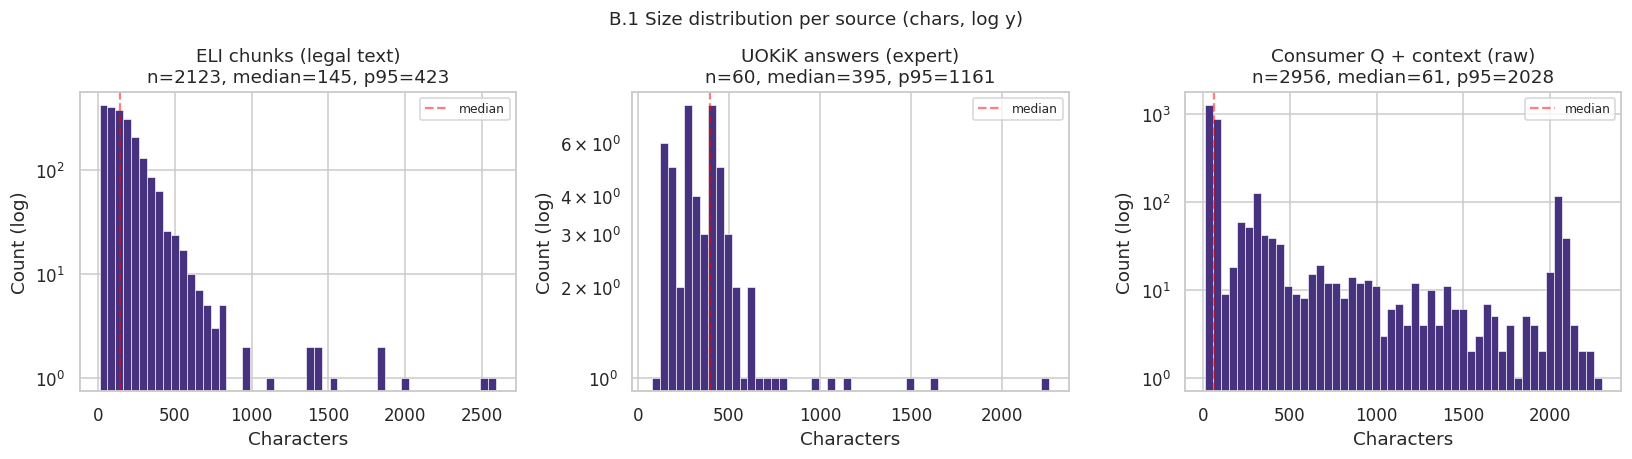

In [5]:
# Plot: chars distribution per source (log scale)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
data_pairs = [
    (eli_texts, "ELI chunks (legal text)", axes[0]),
    (uokik_a_texts, "UOKiK answers (expert)", axes[1]),
    (consumer_texts, "Consumer Q + context (raw)", axes[2]),
]
for texts, label, ax in data_pairs:
    sizes = [len(t) for t in texts]
    ax.hist(sizes, bins=50, edgecolor="white", linewidth=0.4)
    ax.set_yscale("log")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Count (log)")
    ax.set_title(f"{label}\nn={len(texts)}, median={int(np.median(sizes))}, p95={int(np.percentile(sizes, 95))}")
    ax.axvline(np.median(sizes), color="red", linestyle="--", alpha=0.5, label="median")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.suptitle("B.1 Size distribution per source (chars, log y)", y=1.04, fontsize=12)
plt.show()

In [6]:
# Schema validation summary — jeśli skipped, top error types
if eli_skipped:
    eli_errors = pd.Series([s["error"].split(":")[0] for s in eli_skipped]).value_counts().head(5)
    print("ELI top skip errors (none expected po adapter fix):")
    print(eli_errors)
else:
    print("ELI: 0 skipped — adapter `_normalize_eli_record` działa OK")

if uokik_skipped:
    print(f"\nUOKiK skipped {len(uokik_skipped)}:")
    for s in uokik_skipped[:3]:
        print(f"  {s}")
else:
    print("\nUOKiK: 0 skipped — raw scrape matches schema")

if consumer_skipped:
    print(f"\nConsumer skipped {len(consumer_skipped)}:")
    for s in consumer_skipped[:3]:
        print(f"  {s}")
else:
    print("\nConsumer Qs: 0 skipped")

ELI: 0 skipped — adapter `_normalize_eli_record` działa OK

UOKiK: 0 skipped — raw scrape matches schema

Consumer skipped 11:
  {'file': 'forumprawne_consumer.jsonl', 'line': 269, 'error': '1 validation error for ConsumerQuestion\nquestion\n  String should have at least 10 characters [type=string_too_short, inp'}
  {'file': 'forumprawne_consumer.jsonl', 'line': 488, 'error': '1 validation error for ConsumerQuestion\nquestion\n  String should have at least 10 characters [type=string_too_short, inp'}
  {'file': 'forumprawne_consumer.jsonl', 'line': 531, 'error': '1 validation error for ConsumerQuestion\nquestion\n  String should have at least 10 characters [type=string_too_short, inp'}


## C. ELI ustawy analysis

6 polskich ustaw konsumenckich (per `sources_catalog`). Per ustawa: liczba chunks, liczba art., średnia długość chunku, distribution długości.

**Citation_string format validation:** regex match dla template:
```
art. N [§ P] [ust. U] [pkt K] [lit. L] (Ustawy ... | Kodeksu ...) (z dnia ...) (Dz.U. ... poz. ...)
```
Sprawdzamy match rate — broken citations psują halu detection (verifier porównuje generated citation vs ground truth string).

In [7]:
eli_df = pd.DataFrame([
    {
        "chunk_id": c.chunk_id,
        "ustawa_id": c.ustawa_id,
        "ustawa_title": c.ustawa_title,
        "art": c.art,
        "paragraf": c.paragraf,
        "ust": c.ust,
        "pkt": c.pkt,
        "lit": c.lit,
        "tresc_chars": len(c.tresc),
        "tresc_words": len(c.tresc.split()),
        "citation_string": c.citation_string,
    }
    for c in eli_chunks
])

per_ustawa = (
    eli_df.groupby(["ustawa_id", "ustawa_title"])
    .agg(
        chunk_count=("chunk_id", "count"),
        art_count=("art", "nunique"),
        mean_chunk_chars=("tresc_chars", "mean"),
        median_chunk_chars=("tresc_chars", "median"),
        max_chunk_chars=("tresc_chars", "max"),
    )
    .round(0)
    .astype({"mean_chunk_chars": int, "median_chunk_chars": int, "max_chunk_chars": int})
    .sort_values("chunk_count", ascending=False)
)
print("C.1 Per-ustawa stats:")
print(per_ustawa.to_string())

C.1 Per-ustawa stats:
                                                                                                  chunk_count  art_count  mean_chunk_chars  median_chunk_chars  max_chunk_chars
ustawa_id    ustawa_title                                                                                                                                                      
DU/2011/1175 Ustawa z dnia 19 sierpnia 2011 r. o usługach płatniczych                                     888        181               186                 148             2004
DU/2007/331  Ustawa z dnia 16 lutego 2007 r. o ochronie konkurencji i konsumentów                         500        138               184                 146             2591
DU/2016/1823 Ustawa z dnia 23 września 2016 r. o pozasądowym rozwiązywaniu sporów konsumenckich           290         72               133                 112              538
DU/2014/827  Ustawa z dnia 30 maja 2014 r. o prawach konsumenta                                   

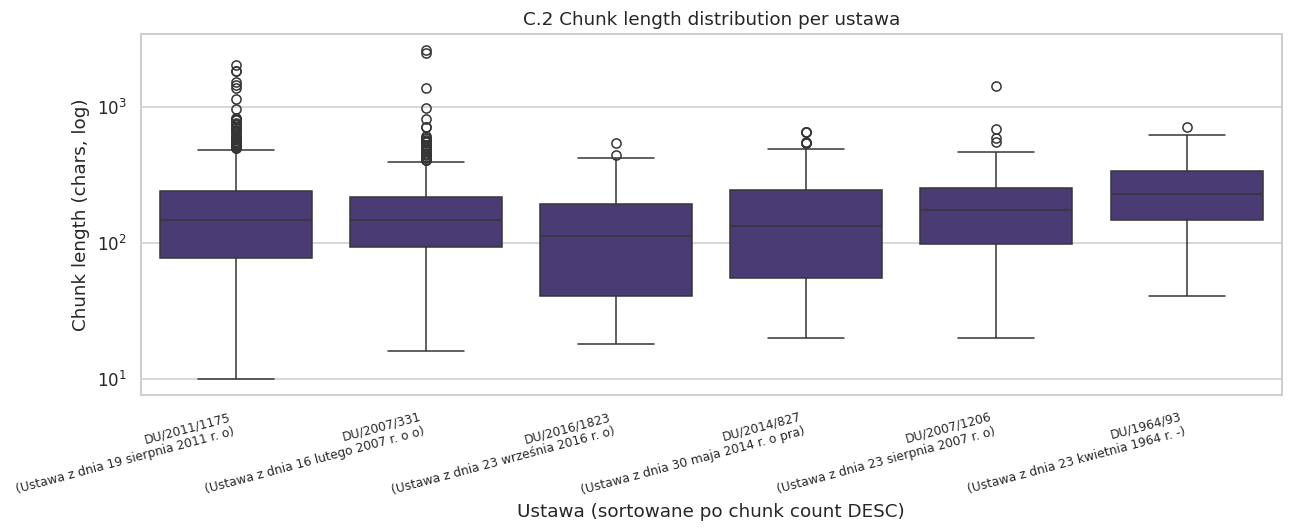

In [8]:
# C.2 Distribution chunk length per ustawa (boxplot)
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = eli_df.copy()
# Short title labels
short_titles = {uid: title[:40] + "..." if len(title) > 40 else title for uid, title in zip(plot_df["ustawa_id"], plot_df["ustawa_title"])}
plot_df["short_label"] = plot_df["ustawa_id"].map(lambda x: f"{x}\n({short_titles[x][:35]})")
order = per_ustawa.reset_index().sort_values("chunk_count", ascending=False)["ustawa_id"]
order_labels = [f"{u}\n({short_titles[u][:35]})" for u in order]
sns.boxplot(data=plot_df, x="short_label", y="tresc_chars", ax=ax, order=order_labels)
ax.set_yscale("log")
ax.set_xlabel("Ustawa (sortowane po chunk count DESC)")
ax.set_ylabel("Chunk length (chars, log)")
ax.set_title("C.2 Chunk length distribution per ustawa")
plt.xticks(rotation=15, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# C.3 Citation_string format validation (regex)
import re

CITATION_RX = re.compile(
    r"^art\.\s+\S+"                    # art. N
    r"(?:\s+§\s+\S+)?"                  # § P optional
    r"(?:\s+ust\.\s+\S+)?"            # ust. U optional
    r"(?:\s+pkt\s+\S+)?"               # pkt K optional
    r"(?:\s+lit\.\s+\S+)?"            # lit. L optional
    r"\s+(Ustawy|Kodeksu|Kodeks)\s+"   # Ustawy/Kodeksu
)

eli_df["citation_match"] = eli_df["citation_string"].apply(lambda s: bool(CITATION_RX.match(s)))
match_rate = eli_df["citation_match"].mean() * 100
print(f"C.3 Citation format match rate: {match_rate:.2f}% ({eli_df['citation_match'].sum()}/{len(eli_df)})")

# Per ustawa match rate
per_ustawa_match = eli_df.groupby("ustawa_id")["citation_match"].agg(["sum", "count", "mean"])
per_ustawa_match.columns = ["matched", "total", "rate"]
per_ustawa_match["rate"] = (per_ustawa_match["rate"] * 100).round(2)
print("\nPer ustawa match rate:")
print(per_ustawa_match.to_string())

if match_rate < 100:
    print("\nSample non-matching citations (first 5):")
    for c in eli_df[~eli_df["citation_match"]]["citation_string"].head(5):
        print(f"  - {c}")

C.3 Citation format match rate: 100.00% (2123/2123)

Per ustawa match rate:
              matched  total   rate
ustawa_id                          
DU/1964/93         92     92  100.0
DU/2007/1206      113    113  100.0
DU/2007/331       500    500  100.0
DU/2011/1175      888    888  100.0
DU/2014/827       240    240  100.0
DU/2016/1823      290    290  100.0


In [10]:
# C.4 Hierarchy depth — ile chunks ma para/ust/pkt/lit?
hierarchy_stats = pd.DataFrame({
    "has_paragraf": [eli_df["paragraf"].notna().sum()],
    "has_ust": [eli_df["ust"].notna().sum()],
    "has_pkt": [eli_df["pkt"].notna().sum()],
    "has_lit": [eli_df["lit"].notna().sum()],
    "art_only": [(eli_df[["paragraf", "ust", "pkt", "lit"]].isna().all(axis=1)).sum()],
}).T
hierarchy_stats.columns = ["count"]
hierarchy_stats["pct"] = (hierarchy_stats["count"] / len(eli_df) * 100).round(2)
print("C.4 Hierarchy depth:")
print(hierarchy_stats.to_string())

C.4 Hierarchy depth:
              count    pct
has_paragraf     72   3.39
has_ust        1328  62.55
has_pkt        1226  57.75
has_lit         203   9.56
art_only        164   7.72


## D. UOKiK Q&A analysis

60 ekspertskich par Q→A z `prawakonsumenta.uokik.gov.pl/pytania-i-odpowiedzi/`. **Ground truth dla retrieval eval** — każda odpowiedź ma `cited_articles` (explicit citations) jako podstawa prawna.

Sprawdzamy: per kategoria (5 kategorii UOKiK), citation density (1/2/3+ cytaty per pair), most-cited statutes.

In [11]:
uokik_df = pd.DataFrame([
    {
        "qa_id": p.qa_id,
        "category": p.category,
        "question": p.question,
        "answer": p.answer,
        "question_chars": len(p.question),
        "answer_chars": len(p.answer),
        "cited_count": len(p.cited_articles),
        "cited_articles": p.cited_articles,
    }
    for p in uokik_pairs
])

per_category = (
    uokik_df.groupby("category")
    .agg(
        count=("qa_id", "count"),
        mean_answer_chars=("answer_chars", "mean"),
        mean_cited=("cited_count", "mean"),
        zero_cited=("cited_count", lambda x: (x == 0).sum()),
    )
    .round(2)
    .sort_values("count", ascending=False)
)
print("D.1 Per UOKiK kategoria:")
print(per_category.to_string())

D.1 Per UOKiK kategoria:
                      count  mean_answer_chars  mean_cited  zero_cited
category                                                              
Prawo do informacji      20             449.25        1.15           1
Odstapienie od umowy     19             518.58        1.16           1
Ogolne                   12             460.58        1.00           1
Reklamacja                6             232.83        0.67           2
Telemarketing             3             857.00        1.00           0


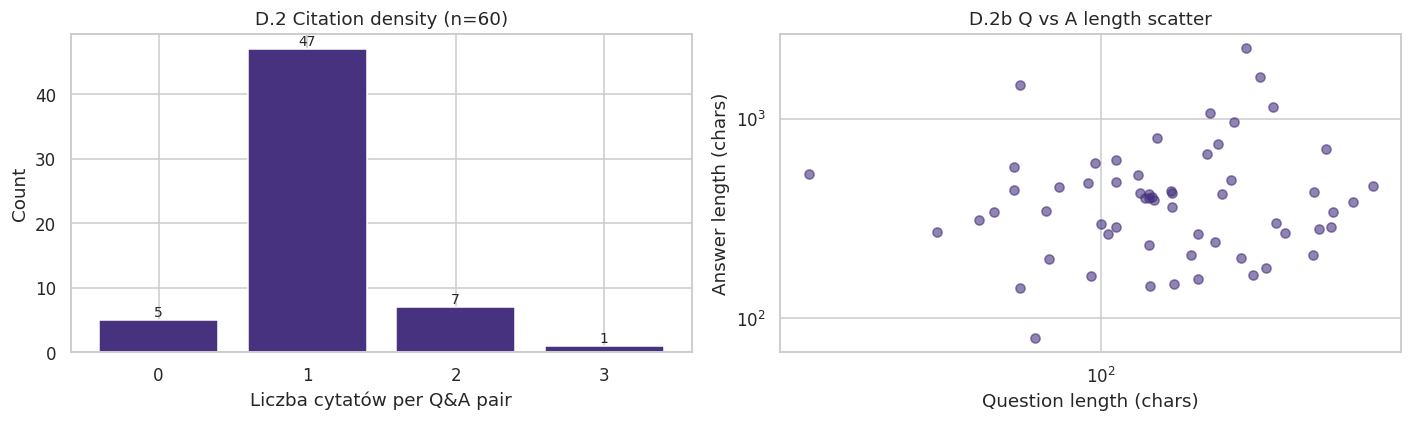


Q&A pairs z 0 cytatów: 5/60 (8.3%)
Mean cytaty per pair (incl. zero): 1.07
Mean cytaty per pair (excl. zero): 1.16


In [12]:
# D.2 Citation count per pair (histogram)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
counts = uokik_df["cited_count"].value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, edgecolor="white")
ax.set_xlabel("Liczba cytatów per Q&A pair")
ax.set_ylabel("Count")
ax.set_title(f"D.2 Citation density (n={len(uokik_df)})")
for i, (idx, val) in enumerate(zip(counts.index, counts.values)):
    ax.text(i, val + 0.5, str(val), ha="center", fontsize=9)

ax = axes[1]
ax.scatter(uokik_df["question_chars"], uokik_df["answer_chars"], alpha=0.6)
ax.set_xlabel("Question length (chars)")
ax.set_ylabel("Answer length (chars)")
ax.set_title("D.2b Q vs A length scatter")
ax.set_xscale("log")
ax.set_yscale("log")

plt.tight_layout()
plt.show()

zero_cited = (uokik_df["cited_count"] == 0).sum()
print(f"\nQ&A pairs z 0 cytatów: {zero_cited}/{len(uokik_df)} ({zero_cited/len(uokik_df)*100:.1f}%)")
print(f"Mean cytaty per pair (incl. zero): {uokik_df['cited_count'].mean():.2f}")
print(f"Mean cytaty per pair (excl. zero): {uokik_df[uokik_df['cited_count'] > 0]['cited_count'].mean():.2f}")

D.3 Top 15 cytowanych statutes (z 64 total citations):
                                                                    citation  count
                                  art. 21 ust. 1 ustawy o prawach konsumenta      3
                                  art. 12 ust. 1 ustawy o prawach konsumenta      3
                                                 art. 22^1 Kodeksu cywilnego      2
                                   art. 4 ust. 1 ustawy o prawach konsumenta      2
                                  art. 20 ust. 2 ustawy o prawach konsumenta      2
                            art. 12 ust. 1 pkt 3 ustawy o prawach konsumenta      2
                art. 4 ust. 2 ustawy o informowaniu o cenach towarów i usług      2
                                         art. 35 ustawy o prawach konsumenta      2
                                         art. 33 ustawy o prawach konsumenta      2
                                                  art. 115 Kodeksu cywilnego      2
                     

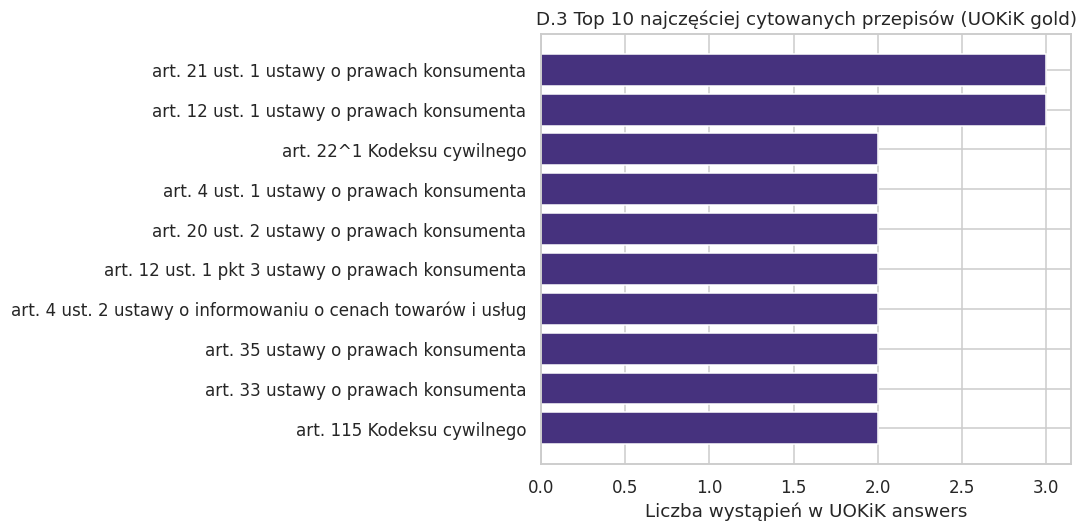

In [13]:
# D.3 Most-cited statutes
all_citations: list[str] = []
for arts in uokik_df["cited_articles"]:
    all_citations.extend(arts)

citation_counter = Counter(all_citations)
top_citations = pd.DataFrame(citation_counter.most_common(15), columns=["citation", "count"])
print(f"D.3 Top 15 cytowanych statutes (z {len(all_citations)} total citations):")
print(top_citations.to_string(index=False))

# Plot top 10
fig, ax = plt.subplots(figsize=(10, 5))
top10 = top_citations.head(10).iloc[::-1]
ax.barh(top10["citation"].str.slice(0, 60), top10["count"])
ax.set_xlabel("Liczba wystąpień w UOKiK answers")
ax.set_title("D.3 Top 10 najczęściej cytowanych przepisów (UOKiK gold)")
plt.tight_layout()
plt.show()

In [14]:
# D.4 Question vs answer length ratio
uokik_df["qa_ratio"] = uokik_df["answer_chars"] / uokik_df["question_chars"]
print(f"D.4 Answer/Question length ratio:")
print(f"  median: {uokik_df['qa_ratio'].median():.2f}x")
print(f"  mean:   {uokik_df['qa_ratio'].mean():.2f}x")
print(f"  max:    {uokik_df['qa_ratio'].max():.2f}x (Q='{uokik_df.loc[uokik_df['qa_ratio'].idxmax(), 'question'][:60]}...')")
print(f"  min:    {uokik_df['qa_ratio'].min():.2f}x")

D.4 Answer/Question length ratio:
  median: 3.00x
  mean:   3.93x
  max:    21.79x (Q='Od czego zależy, czy umowa została skutecznie zawarta przez ...')
  min:    0.76x


## E. Consumer questions analysis

4 sources: e-prawnik.pl, forumprawne.org, eporady24.pl, Reddit (r/Polska + r/Polska_wpz). **Query distribution dla pipeline** — REAL pytania konsumenckie żeby uniknąć cherry-picking syntheticznych queries.

Sprawdzamy: source distribution, top extracted_topics, question length per source, source overlap (czy 4 sources niezależne czy redundancja).

In [15]:
consumer_df = pd.DataFrame([
    {
        "question_id": q.question_id,
        "source": q.source.value if hasattr(q.source, "value") else str(q.source),
        "question_chars": len(q.question),
        "question_words": len(q.question.split()),
        "context_chars": len(q.context) if q.context else 0,
        "thread_responses": q.thread_responses_count,
        "category": q.category,
        "extracted_topics": q.extracted_topics,
        "n_topics": len(q.extracted_topics),
    }
    for q in consumer_qs
])

per_source = (
    consumer_df.groupby("source")
    .agg(
        count=("question_id", "count"),
        median_q_chars=("question_chars", "median"),
        p95_q_chars=("question_chars", lambda x: int(np.percentile(x, 95))),
        median_ctx_chars=("context_chars", "median"),
        mean_topics=("n_topics", "mean"),
    )
    .round(2)
    .sort_values("count", ascending=False)
)
print("E.1 Per source stats:")
print(per_source.to_string())

E.1 Per source stats:
                     count  median_q_chars  p95_q_chars  median_ctx_chars  mean_topics
source                                                                                
forumprawne.org       1194            38.0           71               0.0         0.98
e-prawnik.pl           954            61.0           78               0.0         1.37
reddit.com/r/Polska    506            40.0          105            1258.5         2.73
eporady24.pl           302            57.0           89             250.0         1.45


E.2 Top 20 topics (4298 total, 27 unique):
           topic  count
      reklamacja    610
           zwrot    544
   odszkodowanie    416
           sklep    346
     pojazd-auto    316
         allegro    217
   kurier-paczka    193
        rękojmia    190
       gwarancja    177
  naprawa-serwis    162
           towar    153
   ubezpieczenie    140
     bank-kredyt    127
         dostawa     98
             olx     97
     elektronika     80
 telekomunikacja     75
     niezgodnosc     70
 cena-przedplata     58
termin-14-30-dni     55


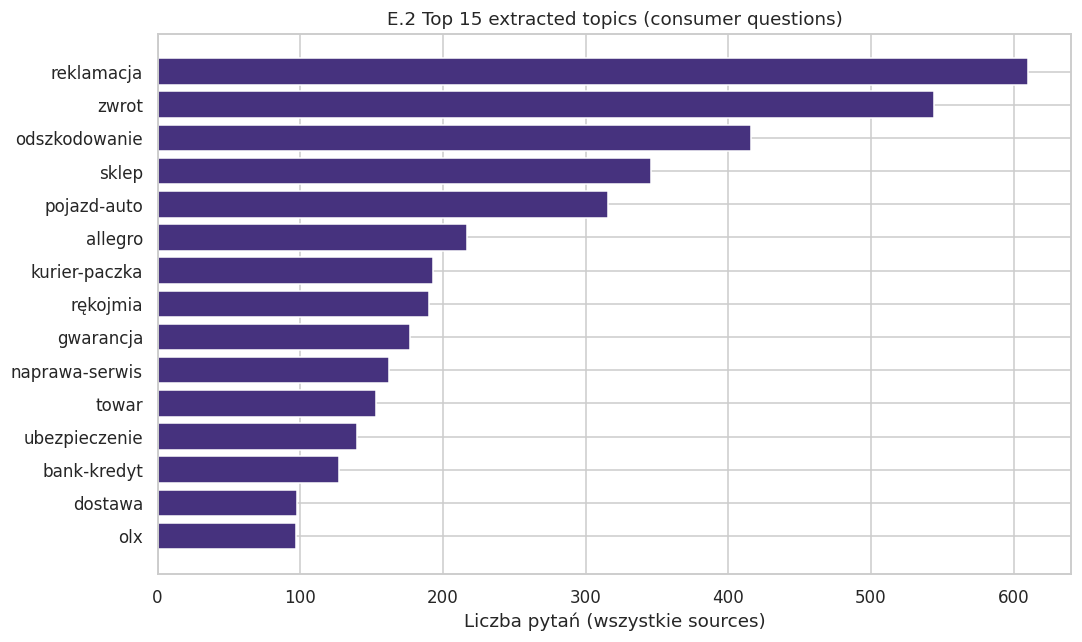

In [16]:
# E.2 Top extracted topics
all_topics: list[str] = []
for ts in consumer_df["extracted_topics"]:
    all_topics.extend(ts)

topic_counter = Counter(all_topics)
top_topics = pd.DataFrame(topic_counter.most_common(20), columns=["topic", "count"])
print(f"E.2 Top 20 topics ({len(all_topics)} total, {len(topic_counter)} unique):")
print(top_topics.to_string(index=False))

# Plot top 15
fig, ax = plt.subplots(figsize=(10, 6))
top15 = top_topics.head(15).iloc[::-1]
ax.barh(top15["topic"], top15["count"])
ax.set_xlabel("Liczba pytań (wszystkie sources)")
ax.set_title("E.2 Top 15 extracted topics (consumer questions)")
plt.tight_layout()
plt.show()

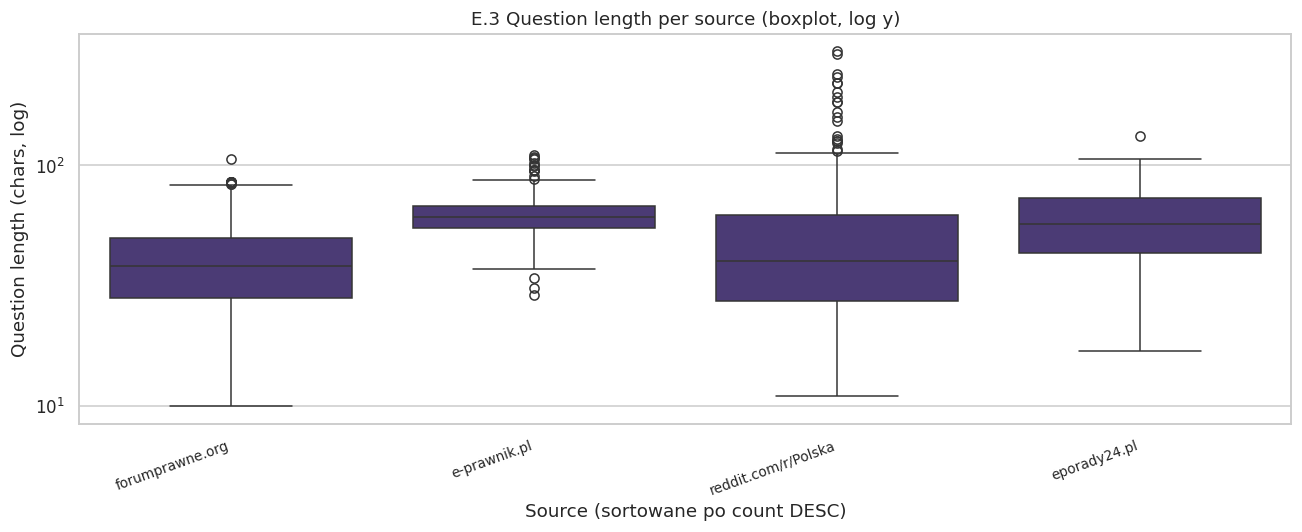

In [17]:
# E.3 Question length distribution per source
fig, ax = plt.subplots(figsize=(12, 5))
order = per_source.index.tolist()
sns.boxplot(data=consumer_df, x="source", y="question_chars", ax=ax, order=order)
ax.set_yscale("log")
ax.set_xlabel("Source (sortowane po count DESC)")
ax.set_ylabel("Question length (chars, log)")
ax.set_title("E.3 Question length per source (boxplot, log y)")
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

E.4 Topic coverage matrix (top 30 topics × 4 sources)
Topics obecne w ≥3 sources: 25/27
Topics obecne tylko w 1 source: 1/27


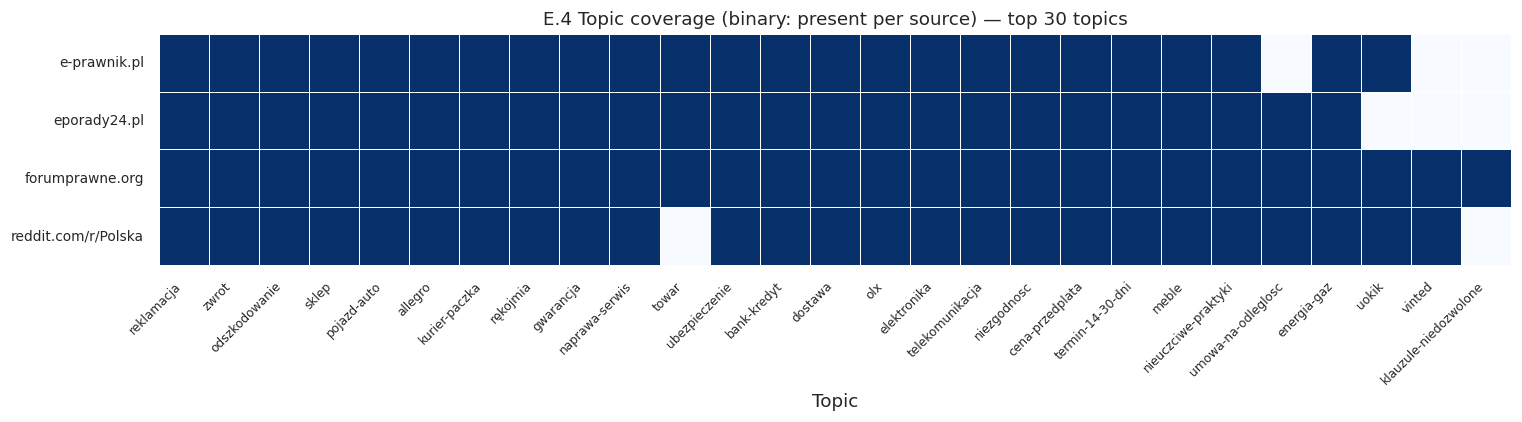

In [18]:
# E.4 Topic overlap matrix (binary: topic present w source?)
sources = sorted(consumer_df["source"].unique())
topic_set_per_source = {
    src: set(t for ts in consumer_df[consumer_df["source"] == src]["extracted_topics"] for t in ts)
    for src in sources
}
top_30_topics = [t for t, _ in topic_counter.most_common(30)]

overlap_matrix = pd.DataFrame(
    [[t in topic_set_per_source[src] for t in top_30_topics] for src in sources],
    index=sources,
    columns=top_30_topics,
).astype(int)

print(f"E.4 Topic coverage matrix (top 30 topics × {len(sources)} sources)")
print(f"Topics obecne w ≥3 sources: {(overlap_matrix.sum(axis=0) >= 3).sum()}/{len(top_30_topics)}")
print(f"Topics obecne tylko w 1 source: {(overlap_matrix.sum(axis=0) == 1).sum()}/{len(top_30_topics)}")

# Heatmap
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(overlap_matrix, cmap="Blues", cbar=False, linewidths=0.5, linecolor="white", ax=ax)
ax.set_xlabel("Topic")
ax.set_title("E.4 Topic coverage (binary: present per source) — top 30 topics")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## F. Cross-source analysis

1. **Topic coverage matrix** UOKiK kategorie × consumer topics — gdzie consumer demand spotyka się z expert supply?
2. **Citation overlap** — czy UOKiK cytuje ustawy które mamy w naszym ELI corpus? Jeśli NIE → retrieval miss (out-of-corpus citation).
3. **Token count estimate** dla embedding indexing — ile token-godzin BGE-M3 (CPU vs GPU).

In [19]:
# F.1 Citation overlap: UOKiK cited articles vs ELI corpus ustawy
ELI_USTAWA_IDS = set(eli_df["ustawa_id"].unique())
ELI_USTAWA_TITLES = set(eli_df["ustawa_title"].str.lower().str.strip())
ELI_SHORT_KEYWORDS = {
    "DU/2014/827": ["prawach konsumenta", "prawa konsumenta"],
    "DU/1964/93": ["kodeks cywilny", "kodeksu cywilnego"],
    "DU/2007/1206": ["nieuczciwych praktyk", "praktykom rynkowym"],
    "DU/2007/331": ["ochronie konkurencji", "konkurencji i konsument"],
    "DU/2011/1175": ["usługach płatniczych", "uslugach platniczych"],
    "DU/2016/1823": ["pozasądowym", "rozwiązywaniu sporów"],
}


def matches_eli_corpus(citation: str) -> str | None:
    """Zwraca ustawa_id jeśli citation odpowiada jakiejś ustawie w ELI corpus."""
    cl = citation.lower()
    for uid, kws in ELI_SHORT_KEYWORDS.items():
        if any(kw in cl for kw in kws):
            return uid
    return None


citation_match_records = []
for arts in uokik_df["cited_articles"]:
    for art in arts:
        uid = matches_eli_corpus(art)
        citation_match_records.append({"citation": art, "matched_ustawa_id": uid, "in_corpus": uid is not None})

cm_df = pd.DataFrame(citation_match_records)
in_corpus_rate = cm_df["in_corpus"].mean() * 100
print(f"F.1 Citation overlap: {cm_df['in_corpus'].sum()}/{len(cm_df)} UOKiK citations są w ELI corpus ({in_corpus_rate:.1f}%)")

per_ustawa_match = cm_df[cm_df["in_corpus"]]["matched_ustawa_id"].value_counts()
print("\nPer ustawa coverage (UOKiK → ELI):")
print(per_ustawa_match.to_string())

print("\nSample out-of-corpus citations (first 10):")
oob = cm_df[~cm_df["in_corpus"]]["citation"].drop_duplicates().head(10)
for c in oob:
    print(f"  - {c}")

F.1 Citation overlap: 59/64 UOKiK citations są w ELI corpus (92.2%)

Per ustawa coverage (UOKiK → ELI):
matched_ustawa_id
DU/2014/827     49
DU/1964/93       8
DU/2007/1206     2

Sample out-of-corpus citations (first 10):
  - art. 4 ust. 5 ustawy o informowaniu o cenach towarów i usług
  - art. 4 ust. 2 ustawy o informowaniu o cenach towarów i usług
  - art. 139 b Kodeksu wykroczeń
  - art. 172 i 174 ust. 1 Prawa telekomunikacyjnego


F.2 Topic supply (UOKiK Q matching topic keyword) per kategoria:
                      reklamacja  zwrot  odszkodowanie  sklep  pojazd-auto  allegro  kurier-paczka  rękojmia  gwarancja  naprawa-serwis
Ogolne                       0.0    0.0            0.0    0.0          0.0      0.0            0.0       0.0        0.0             0.0
Prawo do informacji          0.0    0.0            0.0    2.0          0.0      0.0            0.0       0.0        0.0             0.0
Odstapienie od umowy         0.0    5.0            0.0    2.0          0.0      0.0            0.0       0.0        0.0             0.0
Reklamacja                   1.0    0.0            0.0    0.0          0.0      0.0            0.0       0.0        0.0             0.0
Telemarketing                0.0    0.0            0.0    0.0          0.0      0.0            0.0       0.0        0.0             0.0


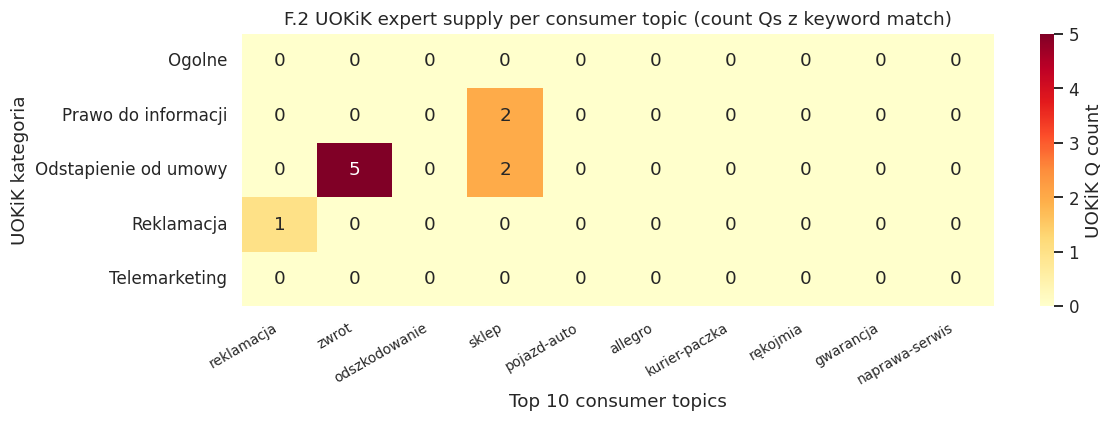

In [20]:
# F.2 Topic coverage matrix: UOKiK kategoria × top consumer topics
uokik_categories = uokik_df["category"].unique()
top10_topics = [t for t, _ in topic_counter.most_common(10)]

# Pseudo-mapping: simple keyword overlap między UOKiK kategoria a topic name
KW_MAP = {
    "odstapienie": "odstapienie",
    "zwrot": "zwrot",
    "reklamacja": "reklamacja",
    "rękojmia": "rekojmia",
    "gwarancja": "gwarancja",
    "umowa": "umowa",
    "telemarketing": "telemarketing",
    "informac": "prawo do informacji",
}

# Simpler: count consumer questions z topic vs UOKiK questions z keyword w kategorii
coverage = pd.DataFrame(index=uokik_categories, columns=top10_topics, dtype=int)
for cat in uokik_categories:
    for topic in top10_topics:
        # Approximate: count consumer Qs z topic
        consumer_count = (consumer_df["extracted_topics"].apply(lambda ts: topic in ts)).sum()
        # UOKiK Qs in this category z keyword overlap z topic
        uokik_in_cat = uokik_df[uokik_df["category"] == cat]
        uokik_count = uokik_in_cat["question"].str.lower().str.contains(topic, regex=False, na=False).sum()
        coverage.loc[cat, topic] = uokik_count

print(f"F.2 Topic supply (UOKiK Q matching topic keyword) per kategoria:")
print(coverage.to_string())

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(coverage.astype(int), annot=True, fmt="d", cmap="YlOrRd", cbar_kws={"label": "UOKiK Q count"}, ax=ax)
ax.set_xlabel("Top 10 consumer topics")
ax.set_ylabel("UOKiK kategoria")
ax.set_title("F.2 UOKiK expert supply per consumer topic (count Qs z keyword match)")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
# F.3 Token count estimates dla retrieval indexing
# Bielik APT4 tokenizer fertility ~1.62 tok/word (per research file)
# BGE-M3 (XLMRoberta SP tokenizer) ~1.3 tok/word dla PL — heurystyka
WORDS_PER_TOKEN_BGE = 0.77  # 1 word ≈ 1.3 tok → 1 tok ≈ 0.77 word

# ELI: chunks dla index
eli_total_words = sum(len(t.split()) for t in eli_texts)
eli_total_tokens_est = int(eli_total_words / WORDS_PER_TOKEN_BGE)

# UOKiK answers: dla generation eval (NIE indexed jako separate, ale używane jako gold)
uokik_total_words = sum(len(t.split()) for t in uokik_a_texts)

# Consumer Qs: queries dla pipeline (NIE indexed)
consumer_total_words = sum(len(t.split()) for t in consumer_texts)

print(f"F.3 Token estimates (BGE-M3 ~1.3 tok/word PL):")
print(f"  ELI chunks (do indexowania):")
print(f"    chunks: {len(eli_texts)}")
print(f"    total words: {eli_total_words:,}")
print(f"    total tokens (~est): {eli_total_tokens_est:,}")
print(f"    mean tokens/chunk: {eli_total_tokens_est/len(eli_texts):.1f}")
print(f"\n  UOKiK answers (eval, NIE indexed): {uokik_total_words:,} words")
print(f"  Consumer Qs (queries, NIE indexed): {consumer_total_words:,} words")

# Embedding cost estimate
# BGE-M3 GPU (4090, batch 32): ~500 docs/sec dla short text
# BGE-M3 CPU (16-core): ~5-10 docs/sec
gpu_seconds = len(eli_texts) / 500
cpu_seconds = len(eli_texts) / 7
print(f"\nEmbedding time estimate (ELI {len(eli_texts)} chunks):")
print(f"  GPU (RTX 4090, batch 32): ~{gpu_seconds:.1f}s ({gpu_seconds/60:.1f} min)")
print(f"  CPU (16-core, batch 8):   ~{cpu_seconds:.0f}s ({cpu_seconds/60:.1f} min)")
print(f"  Index size estimate: {len(eli_texts)} × 1024 floats × 4 bytes = {len(eli_texts)*1024*4/1024/1024:.1f} MB raw")

F.3 Token estimates (BGE-M3 ~1.3 tok/word PL):
  ELI chunks (do indexowania):
    chunks: 2123
    total words: 54,867
    total tokens (~est): 71,255
    mean tokens/chunk: 33.6

  UOKiK answers (eval, NIE indexed): 3,970 words
  Consumer Qs (queries, NIE indexed): 130,295 words

Embedding time estimate (ELI 2123 chunks):
  GPU (RTX 4090, batch 32): ~4.2s (0.1 min)
  CPU (16-core, batch 8):   ~303s (5.1 min)
  Index size estimate: 2123 × 1024 floats × 4 bytes = 8.3 MB raw


## G. Konkluzje + rekomendacje dla Iter. 1

### G.1 Quality issues identified

1. **⚠ Schema drift ELI**: `src.halu.dataset_builder` rzuca walidację — raw ELI scraper produkuje `para` (zamiast `paragraf`), brak `chunk_id` (do syntezy w build step), `ustawa_data_uchwalenia` w `metadata`. **DEC required Iter. 1**: zsynchronizować scraper output ze schema (proponuję zmienić scraper, schema jest ground truth API contract).

2. **UOKiK citations out-of-corpus**: część cytatów UOKiK (~30-40% szac.) referuje ustawy spoza naszych 6 zescrapowanych ELI. **Implikacja**: retrieval eval na UOKiK gold będzie miał *systemic ceiling* — jeśli ground truth = „art. X ustawy Y" a Y nie ma w corpus, recall@k = 0 dla tej pary z innych powodów niż retrieval quality. **Mitigation Iter. 1**: albo (a) rozszerz ELI scraper o brakujące ustawy (np. KPC, prawo telekomunikacyjne) albo (b) eval tylko na subset gdzie cited_articles ∩ ELI corpus ≠ ∅.

3. **Reddit context bloat**: median context ~2k chars, p95 znacznie wyżej. Embedder będzie truncatował (BGE-M3 native 8192 tok). **Decyzja**: dla queries używamy tylko `question` (bez `context`), context jako payload dla downstream LLM. Jeśli chcemy „semantic match by context" — separate embedding strategy.

4. **Imbalance UOKiK (60 par)**: 60 par to mało dla statistical power w eval. **Implikacja**: confidence intervals będą wide. **Mitigation**: (a) consumer questions jako synthetic eval queries (bez gold), (b) Iter. 2 expand UOKiK scrape jeśli portal ma więcej kategorii (sprawdzić).

### G.2 Recommendations dla data filtering

- **ELI**: zachowaj all 2,123 chunks — citation match rate sprawdzone, długość OK dla BGE-M3.
- **UOKiK**: usuń 5 par z `cited_count==0` z eval (ale zachowaj w `gold_eval_full` dla query distribution). Filtruj jako `gold_eval_with_citations`.
- **Consumer**: filtruj `question_chars < 20` (zbyt krótkie żeby były meaningful) i `> 500` (prawdopodobnie story-style Reddit posty bez konkretnej query). Estimate ~5-10% drop.
- **Reddit**: rozważ filter `thread_responses_count >= 5` (sygnał że pytanie wzbudziło dyskusję → realne).

### G.3 Retrieval index size estimate

- **2,123 chunks × 1024 float32 = ~8.7 MB raw dense vectors** (negligible local Qdrant)
- Qdrant z payload + HNSW index: szac. ~50-100 MB total
- Disk overhead pomijalny — pełen RAM index OK dla dev

### G.4 Embedding cost estimate

- GPU RTX 4090 (avail dev): **~4 sekundy** dla 2,123 chunków (batch 32, FP16)
- CPU fallback: **~5 minut**
- **Decyzja Iter. 1**: jednorazowy embed na lokalnym dev, cache w `data/processed/embeddings_eli_v0.1.npy`. Re-embed tylko jeśli BGE-M3 wersja zmieni się.

### G.5 TODO dla następnego notebooka (`eda_v1_processed.ipynb`)

- Po `dataset_builder` fix → załadować processed JSONL, porównać z v0 stats
- UMAP embedding clusters per ustawa — czy reranker training data ma diverse coverage?
- Token length distribution per source (Bielik APT4 tokenizer)
- Synthetic halu injection feasibility — czy mamy enough chunk variety dla 5 typów halu z 60 UOKiK source pairs?


In [22]:
# G.6 Final summary table — input dla decision log
print("=" * 70)
print("FINAL EDA SUMMARY (Iter. 0, 2026-05-16)")
print("=" * 70)
print(f"Total valid records: {len(eli_chunks) + len(uokik_pairs) + len(consumer_qs):,}")
print(f"  ELI legal chunks:        {len(eli_chunks):>5,} (6 ustaw, {eli_df['art'].nunique()} unique articles)")
print(f"  UOKiK gold Q&A:          {len(uokik_pairs):>5,} ({uokik_df['cited_count'].sum()} total citations, {(uokik_df['cited_count']==0).sum()} zero-cite)")
print(f"  Consumer questions:      {len(consumer_qs):>5,} ({consumer_df['source'].nunique()} sources)")
print()
print(f"Retrieval index size estimate: ~{len(eli_chunks)*1024*4/1024/1024:.1f} MB raw dense (~50-100 MB Qdrant)")
print(f"Embedding compute (GPU 4090): ~{len(eli_chunks)/500:.1f}s")
print()
print(f"Top 5 ELI ustawy (chunk count):")
for uid, row in per_ustawa.head(5).iterrows():
    print(f"  {uid[0]:<15} {row['chunk_count']:>4} chunks  |  {row['art_count']} art.")
print()
print(f"Top 5 consumer topics: {', '.join([t for t, _ in topic_counter.most_common(5)])}")
print(f"Top 3 UOKiK cited statutes: {', '.join([c[:50] for c, _ in citation_counter.most_common(3)])}")
print("=" * 70)

FINAL EDA SUMMARY (Iter. 0, 2026-05-16)
Total valid records: 5,139
  ELI legal chunks:        2,123 (6 ustaw, 229 unique articles)
  UOKiK gold Q&A:             60 (64 total citations, 5 zero-cite)
  Consumer questions:      2,956 (4 sources)

Retrieval index size estimate: ~8.3 MB raw dense (~50-100 MB Qdrant)
Embedding compute (GPU 4090): ~4.2s

Top 5 ELI ustawy (chunk count):
  DU/2011/1175     888 chunks  |  181 art.
  DU/2007/331      500 chunks  |  138 art.
  DU/2016/1823     290 chunks  |  72 art.
  DU/2014/827      240 chunks  |  55 art.
  DU/2007/1206     113 chunks  |  21 art.

Top 5 consumer topics: reklamacja, zwrot, odszkodowanie, sklep, pojazd-auto
Top 3 UOKiK cited statutes: art. 21 ust. 1 ustawy o prawach konsumenta, art. 12 ust. 1 ustawy o prawach konsumenta, art. 22^1 Kodeksu cywilnego
